In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, f1_score, precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
import joblib

In [2]:
# read dataset into memory
df = pd.read_csv('../Data/global_placement.csv')
# get the first 5 datapoints in the dataset
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,salary
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed,104124.367838
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed,80586.838313
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed,114444.318097
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed,120000.000000
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed,120000.000000


In [3]:
# get the last 5 datapoints in the dataset
df.tail()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,salary
9995,8.040882,0,Tier 3,USA,100-300,2,98.120449,80.866213,Data Science,Manufacturing,6.298524,Placed,109831.584346
9996,5.401324,3,Tier 1,UK,100-300,1,68.622854,83.458035,Data Science,Consulting,7.352717,Not Placed,0.000000
9997,6.435747,0,Tier 3,UK,300+,2,69.067773,50.992745,Core CS,Other,3.871205,Placed,69818.819355
9998,7.396612,1,Tier 3,Germany,100-300,3,45.050463,86.807882,Cloud,Finance,3.687731,Placed,82797.577423
9999,7.515511,3,Tier 2,UK,300+,4,66.947232,46.385843,AI/ML,Manufacturing,4.181389,Placed,105387.859101


In [4]:
# check for missing values in the dataset
df.isna().sum()

cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
salary                      0
dtype: int64

In [5]:
# checking the unique values in the object columns, which will be used later in feature encoding before model training
cols = ['college_tier', 'country', 'university_ranking_band', 
        'specialization', 'industry', 'placement_status']

for col in cols:
    print(f'In {col} we have the following unique values {df[col].unique()} resulting in {df[col].nunique()}  unique values')
    print('-----------------------------------------------------------------------------------------------------------------')

In college_tier we have the following unique values ['Tier 2' 'Tier 3' 'Tier 1'] resulting in 3  unique values
-----------------------------------------------------------------------------------------------------------------
In country we have the following unique values ['Canada' 'UK' 'USA' 'Germany' 'India'] resulting in 5  unique values
-----------------------------------------------------------------------------------------------------------------
In university_ranking_band we have the following unique values ['100-300' '300+' 'Top 100'] resulting in 3  unique values
-----------------------------------------------------------------------------------------------------------------
In specialization we have the following unique values ['Data Science' 'Cybersecurity' 'AI/ML' 'Core CS' 'Cloud'] resulting in 5  unique values
-----------------------------------------------------------------------------------------------------------------
In industry we have the following unique values ['C

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
 12  salary                    10000 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1015.8+ KB


## Exploratory Data Analysis

In [7]:
# What is the rate of placement?
placement = df[df['placement_status'] == 'Placed']
num_placement = len(placement)
total_number = len(df)
rate_placement = (num_placement / total_number) * 100
print(f'The rate of placement is {round(rate_placement)}%')

The rate of placement is 62%


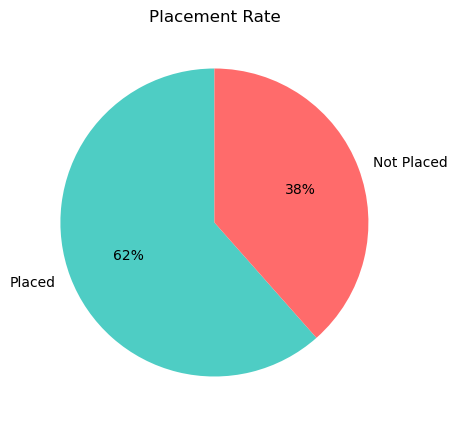

In [8]:
count = df['placement_status'].value_counts()
plt.figure(figsize=(10,5))
plt.pie(
    count,
    labels=count.index,
    autopct='%1.f%%',
    startangle=90,
    colors=[ '#4ecdc4', '#ff6b6b']
)
plt.title('Placement Rate')
# plt.savefig('../Images/placement_pie.png', dpi=300, bbox_inches='tight')
plt.show()

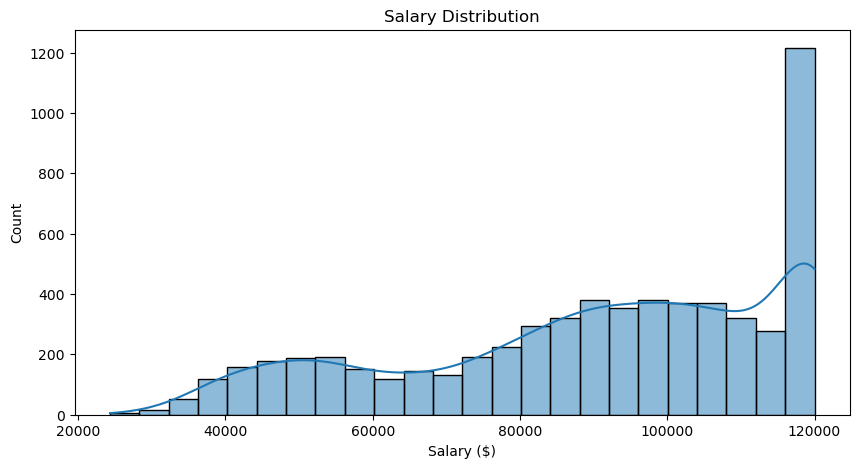

In [9]:
# Salary placement of placed student
plt.figure(figsize=(10,5))
ax = sns.histplot(data=placement, x='salary', kde=True)
ax.set(
    title='Salary Distribution',
    xlabel='Salary ($)',
    ylabel='Count'
)
# plt.savefig('../Images/salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

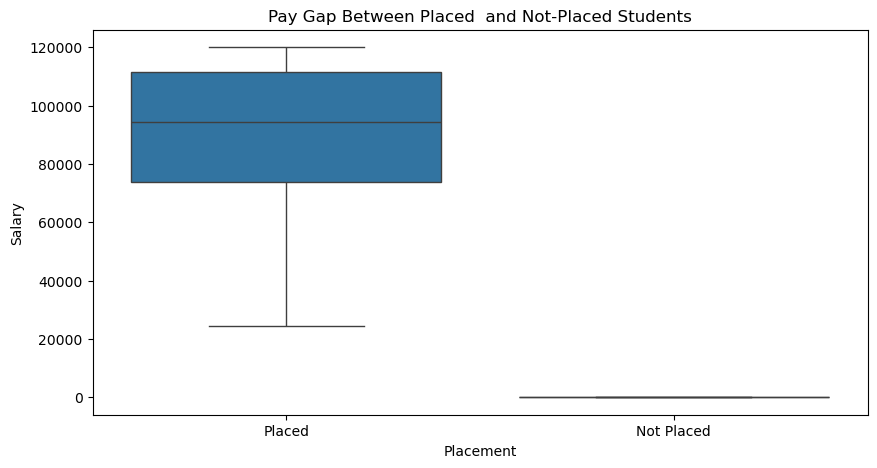

In [10]:
# Is there a pay gap between placed and not placed students?
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='placement_status', y='salary')
ax.set(
    title='Pay Gap Between Placed  and Not-Placed Students',
    xlabel='Placement',
    ylabel='Salary'
)
# plt.savefig('../Images/pay_gap.png', dpi=300, bbox_inches='tight')
plt.show()

Unplaced students recorded a salary of $0, confirming that salary in this dataset is exclusively a placement outcome. All salary analysis going forward focuses on placed students only.

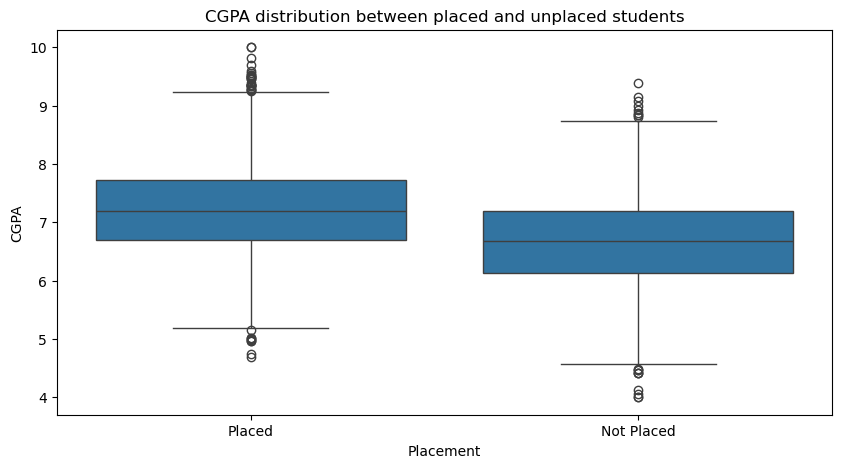

In [11]:
# How does CGPA distribution differ between placed and unplaced students?
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='placement_status', y='cgpa')
ax.set(
    title='CGPA distribution between placed and unplaced students',
    xlabel='Placement',
    ylabel='CGPA'
)
plt.show()

Placed students tend to have higher CGPAs, with a median just above 7, compared to unplaced students whose median falls between 6 and 7. However, the overlapping distributions suggest CGPA is an influencing factor but not a standalone predictor of placement.

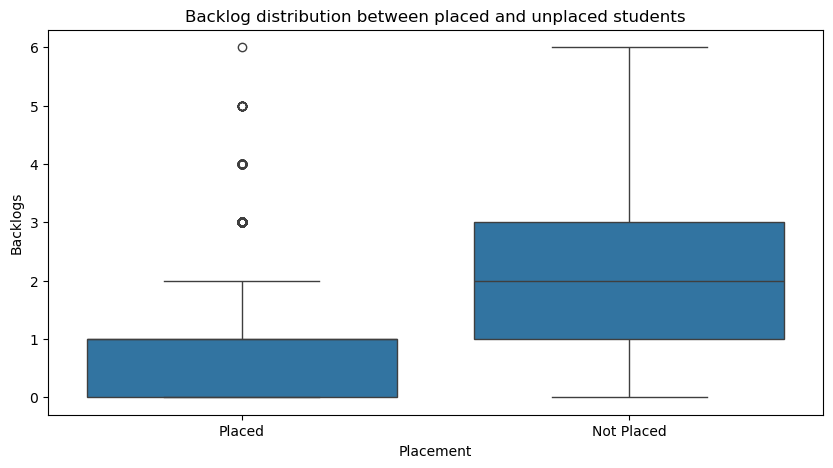

In [12]:
# Do backlogs significantly hurt placement chances at what threshold?
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='placement_status', y='backlogs')
ax.set(
    title='Backlog distribution between placed and unplaced students',
    xlabel='Placement',
    ylabel='Backlogs'
)
# plt.savefig('../Images/backlogs.png', dpi=300, bbox_inches='tight')
plt.show()

Backlogs clearly hurt placement chances. Placed students overwhelmingly have 0–1 backlogs, while unplaced students cluster between 1–3 with a median of 2. The threshold appears to be around 2 backlogs — beyond which placement becomes significantly less likely, though a small number of outliers show it's not entirely impossible.

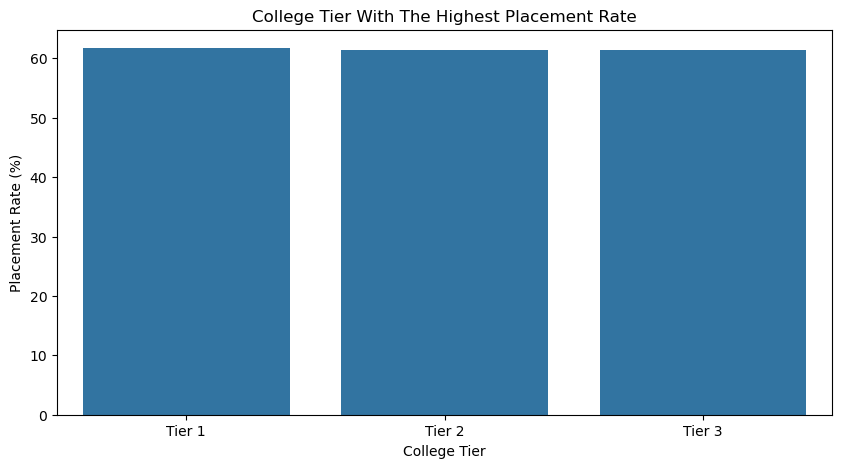

In [13]:
# Which college tier produces the highest placement rate? college_tier
placement_by_tier = df.groupby('college_tier')['placement_status'].apply(
    lambda x: (x == 'Placed').sum()/len(x) * 100
).reset_index()
placement_by_tier.columns = ['college_tier', 'placement_status']
plt.figure(figsize=(10,5))
ax = sns.barplot(data=placement_by_tier, x='college_tier', y='placement_status')
ax.set(
    title='College Tier With The Highest Placement Rate',
    xlabel='College Tier',
    ylabel='Placement Rate (%)'
)
# plt.savefig('../Images/placement_rate_by_tier.png', dpi=300, bbox_inches='tight')
plt.show()

Surprisingly, placement rates are consistent across all college tiers, all hovering around 60%. This suggests that the institution's prestige alone does not determine placement outcome, individual performance metrics such as CGPA, aptitude, and internship experience likely play a stronger role.

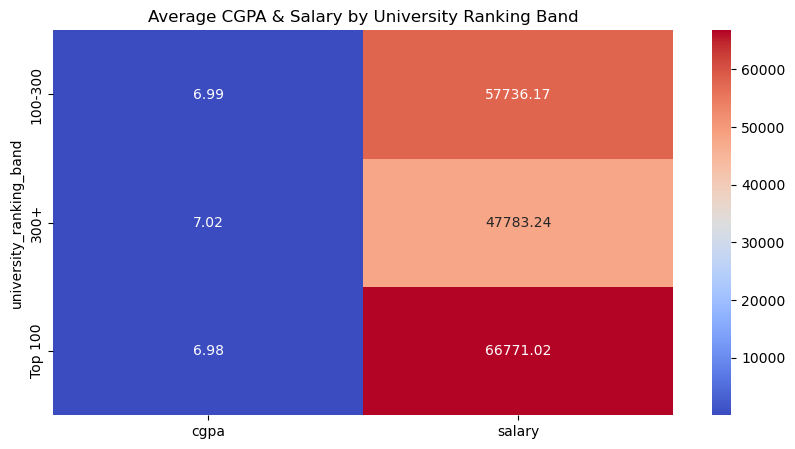

In [14]:
# Does university ranking band correlate with CGPA or salary?
university_ranking = df.groupby('university_ranking_band')[['cgpa', 'salary']].mean()
plt.figure(figsize=(10,5))
ax = sns.heatmap(university_ranking, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Average CGPA & Salary by University Ranking Band')
# plt.savefig('../Images/cgpa_salry_by_uni_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

University ranking band shows no correlation with CGPA, all bands average around 7.0. However, salary tells a different story, with Top 100 graduates earning nearly $19,000 more than those from 300+ ranked institutions, suggesting employer bias and recruiter access play a stronger role than academic performance alone.

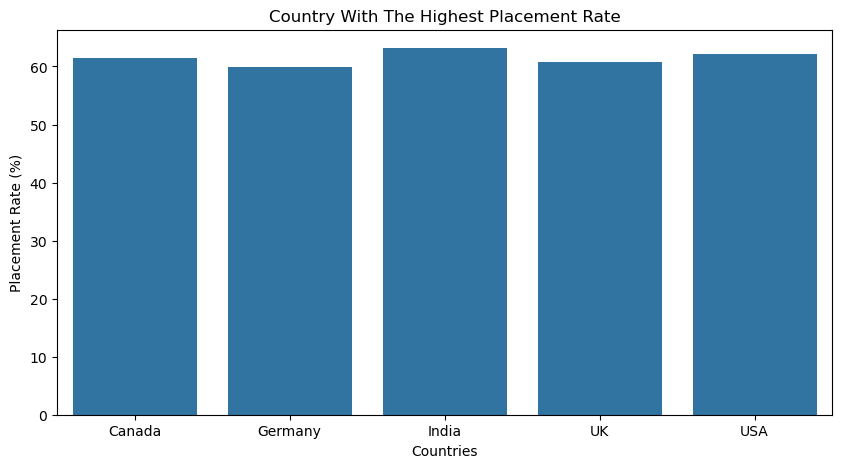

In [15]:
# Which countries have the highest and lowest placement rates?
placement_by_country = df.groupby('country')['placement_status'].apply(
    lambda x: (x == 'Placed').sum() / len(x) * 100
).reset_index()
placement_by_country.columns = ['country', 'placement_status']
plt.figure(figsize=(10,5))
ax = sns.barplot(data=placement_by_country, x='country', y='placement_status')
ax.set(
    title='Country With The Highest Placement Rate',
    xlabel='Countries',
    ylabel='Placement Rate (%)'
)
plt.show()

Placement rates are remarkably consistent across countries, ranging narrowly between 58–63%. India leads marginally while Germany sits at the lower end, but the differences are too small to be meaningful. Combined with similar findings across college tiers, this suggests placement outcome in this dataset is driven by individual attributes rather than institutional or geographic factors.

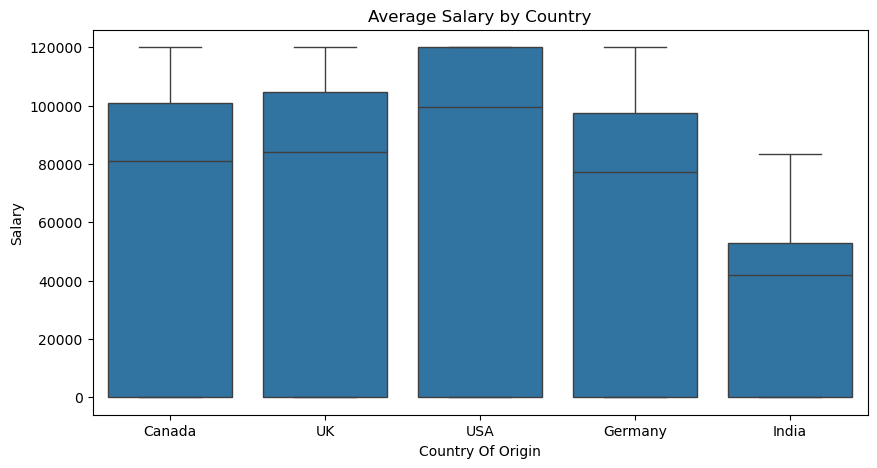

In [16]:
# Does the country of study influence salary for placed students?
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='country', y='salary')
ax.set(
    title='Average Salary by Country',
    xlabel='Country Of Origin',
    ylabel='Salary'
)
# plt.savefig('../Images/average_salary_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

While placement rates are consistent across countries, salary varies dramatically. USA leads with a median of ~100k USD, while India sits significantly lower at ~40k USD a gap of nearly ~60k USD. This reflects differences in local market rates rather than candidate quality, as academic performance remains consistent across all countries.

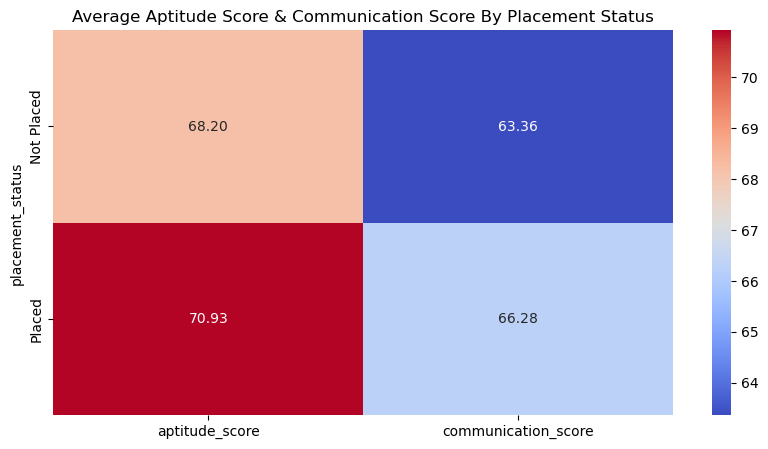

In [17]:
# How do aptitude and communication scores compare between placed vs unplaced students?
apt_comm = df.groupby('placement_status')[['aptitude_score', 'communication_score']].mean()
plt.figure(figsize=(10,5))
sns.heatmap(apt_comm, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Average Aptitude Score & Communication Score By Placement Status')
plt.show()

Placed students score marginally higher in both aptitude (70.93 vs 68.20) and communication (66.28 vs 63.66). While the gaps are not dramatic individually, they follow a consistent pattern across all performance metrics, suggesting placement outcome is the result of cumulative marginal advantages rather than any single standout factor.

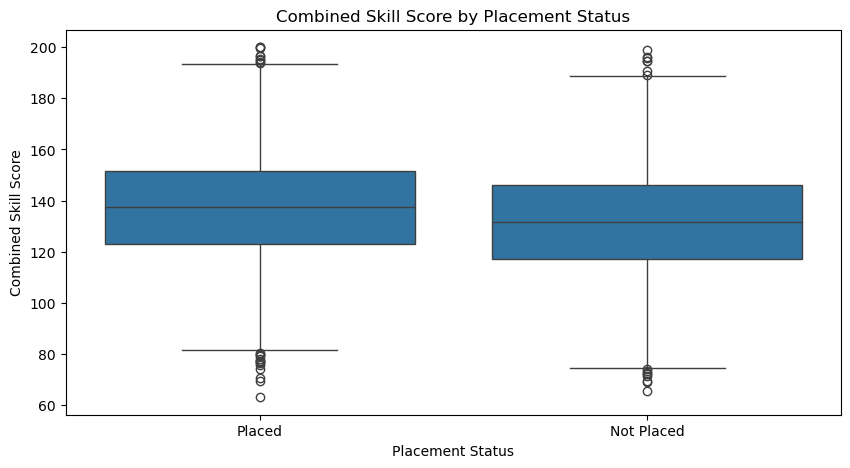

In [18]:
# Is there a combined skill threshold (aptitude + communication) that strongly predicts placement?
df['combined_skill_score'] = df['aptitude_score'] + df['communication_score']
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='placement_status', y='combined_skill_score')
ax.set(
    title='Combined Skill Score by Placement Status',
    xlabel='Placement Status',
    ylabel='Combined Skill Score'
)
plt.show()

A combined aptitude and communication score of ~140 emerges as the soft threshold for placed students, compared to ~130 for unplaced students. While the overlap between groups suggests it's not a definitive cutoff, this engineered feature captures cumulative skill strength more effectively than either score alone and will be carried forward into the model.

The sweet spot is at placement_status
Not Placed    1.194957
Placed        1.689582
Name: internship_count, dtype: float64


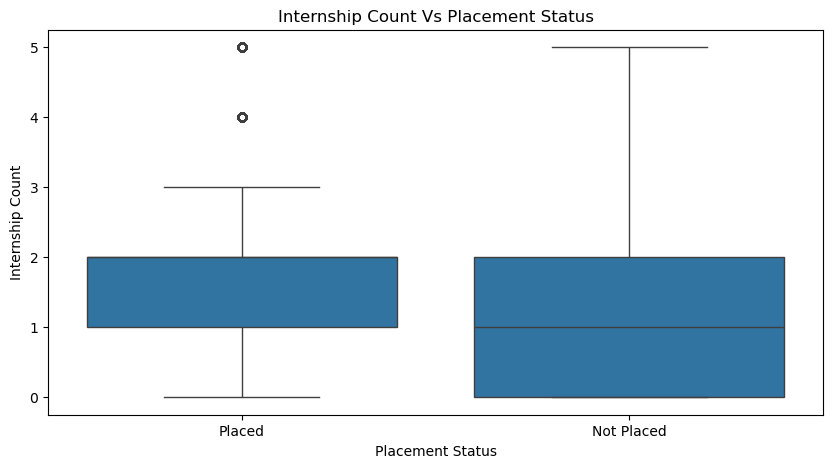

In [19]:
# Does internship count improve placement likelihood? Is there a sweet spot?
sweet_spot = df.groupby('placement_status')['internship_count'].mean()
print(f'The sweet spot is at {sweet_spot}')
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='placement_status', y='internship_count')
ax.set(
    title='Internship Count Vs Placement Status',
    xlabel='Placement Status',
    ylabel='Internship Count'
)
# plt.savefig('../Images/intership_count_by_placement.png', dpi=300, bbox_inches='tight')
plt.show()

Placed students average ~1.7 internships compared to ~1.2 for unplaced students. While the difference seems small, it points to a clear threshold,  moving from 1 to 2 internships is where placement likelihood meaningfully improves. Having zero internships remains a significant disadvantage, and the sweet spot sits firmly in the 1–2 range.

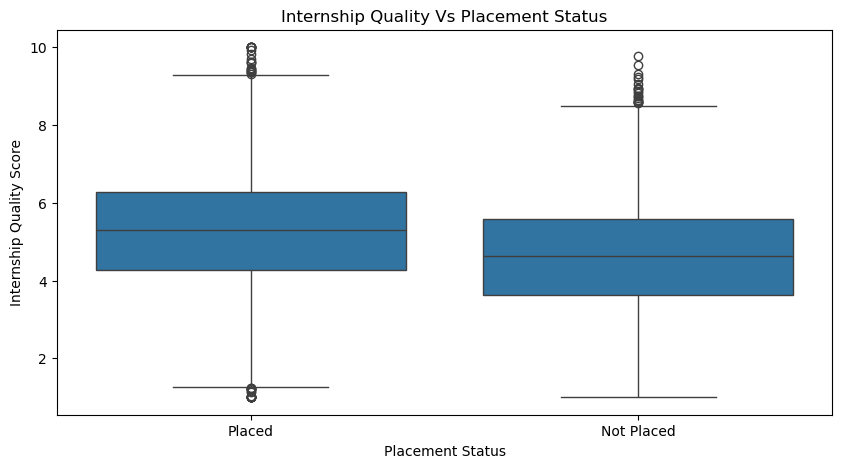

In [20]:
# Does internship quality matter more than internship count for placement?
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='placement_status', y='internship_quality_score')
ax.set(
    title='Internship Quality Vs Placement Status',
    xlabel='Placement Status',
    ylabel='Internship Quality Score'
)
# plt.savefig('../Images/intership_quality_by_placement.png', dpi=300, bbox_inches='tight')
plt.show()

Internship quality shows a more distinct separation between placed and unplaced students than internship count does. The upper range of unplaced students barely reaches the median quality score of placed students, suggesting that the caliber of internship experience is a stronger placement differentiator than the number of internships completed.

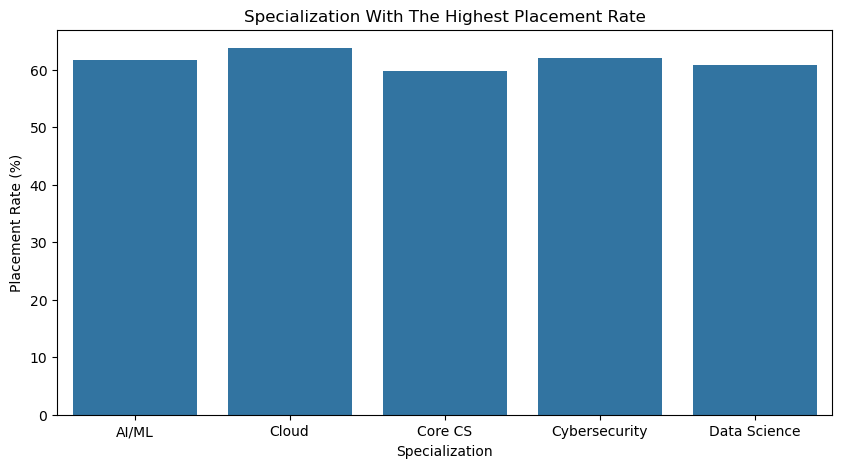

In [21]:
# Which specializations have the highest placement rates?
special = df.groupby('specialization')['placement_status'].apply(
    lambda x: (x == 'Placed').sum() / len(x) * 100
).reset_index()
special.columns = ['specialization', 'placement_status']
plt.figure(figsize=(10,5))
ax = sns.barplot(data=special, x='specialization', y='placement_status')
ax.set(
    title='Specialization With The Highest Placement Rate',
    xlabel='Specialization',
    ylabel='Placement Rate (%)'
)
# plt.savefig('../Images/specialization.png', dpi=300, bbox_inches='tight')
plt.show()

Cloud Computing leads placement rates marginally, followed by AI/ML and Cybersecurity, with Data Science and Core CS sitting right at the 60% mark. However, the differences are negligible, confirming the recurring theme that specialization, like institution and geography, is not a strong driver of placement outcome.

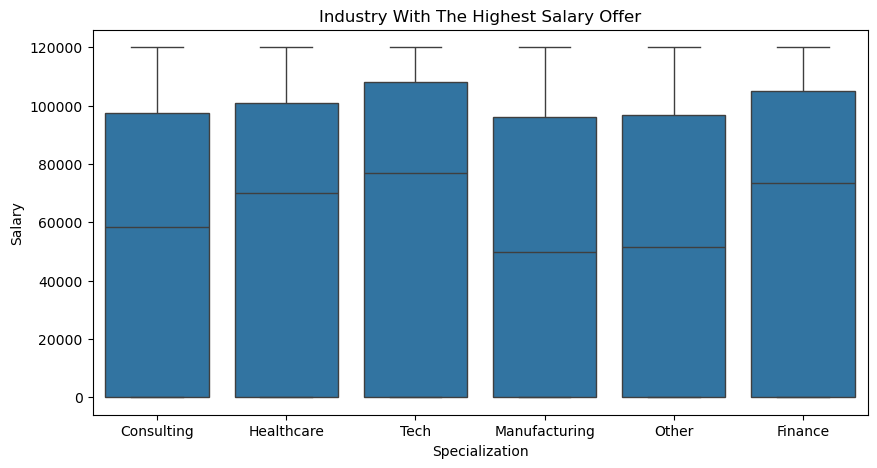

In [22]:
# Which industries offer the highest salaries?
highest_salary = df.groupby('industry')['salary'].mean()
# print(highest_salary)
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='industry', y='salary')
ax.set(
    title='Industry With The Highest Salary Offer',
    xlabel='Specialization',
    ylabel='Salary'
)
# plt.savefig('../Images/industry_salary.png', dpi=300, bbox_inches='tight')
plt.show()

Tech offers the highest median salary at ~80k USD, nearly double that of Manufacturing and Other at ~50k USD. Since all specializations in this dataset are tech-oriented yet average between 51–58k USD, a significant portion of graduates are landing in lower paying industries, suggesting industry placement is a stronger salary determinant than academic specialization.

## Data Splitting, Data Encoding and Model Training

In [23]:
df['placement_status'] = df['placement_status'].map({
    'Placed':1,
    'Not Placed':0
})

In [24]:
# features and target
x = df.drop(columns=['placement_status', 'salary'])
y = df['placement_status']

# splitting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
nominal_cols = [
    'college_tier', 'country', 'university_ranking_band',
    'specialization', 'industry'
]

ohe = OneHotEncoder(
    sparse_output = False,
    handle_unknown = 'ignore'
)

# fit on train, transform on both
train_encoded = ohe.fit_transform(x_train[nominal_cols])
test_encoded = ohe.transform(x_test[nominal_cols])

# convert from array to DataFrame with proper column names
train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=x_train.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=x_test.index
)

# drop original columns and add the encoded columns
x_train = x_train.drop(columns=nominal_cols)
x_test = x_test.drop(columns=nominal_cols)

x_train = pd.concat([x_train, train_encoded_df], axis=1)
x_test = pd.concat([x_test, test_encoded_df], axis=1)

print(f'Training set shape {x_train.shape}')
print(f'Testing set shape {x_test.shape}')

Training set shape (8000, 29)
Testing set shape (2000, 29)


In [26]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

rf_train_pred = rf.predict(x_train)
rf_test_pred = rf.predict(x_test)

print('_____ Random Forest Classifier ______')
print(f'Train Accuracy: {accuracy_score(y_train, rf_train_pred):.3f}')
print(f'Test Accuracy: {accuracy_score(y_test, rf_test_pred):.3f}')
print(f'Gap: {accuracy_score(y_train, rf_train_pred) - accuracy_score(y_test, rf_test_pred):.3f}')
print(f'F1 Score: {f1_score(y_test, rf_test_pred):.3f}')
print(f'Precision: {precision_score(y_test, rf_test_pred):.3f}')
print(f'Recall: {recall_score(y_test, rf_test_pred):.3f}')

_____ Random Forest Classifier ______
Train Accuracy: 1.000
Test Accuracy: 0.747
Gap: 0.253
F1 Score: 0.804
Precision: 0.769
Recall: 0.842


In [27]:
# tuning the model using random search cv to get the best parameters
param_distributions = {
    'n_estimators':[200,300,400],
    'max_depth':[15,20,25],
    'min_samples_split':[5,10,15],
    'min_samples_leaf':[2,4,8]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    cv=5,
    n_iter=20,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(x_train,y_train)

print(f'\n Best Parameter: {random_search.best_params_}')
print(f'Best CV: {random_search.best_score_:.3f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Best Parameter: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_depth': 20}
Best CV: 0.872


In [28]:
best_rf = random_search.best_estimator_
best_rf.fit(x_train,y_train)

train_proba = best_rf.predict_proba(x_train)[:, 1]
test_proba = best_rf.predict_proba(x_test)[:, 1]

threshold = 0.4

best_train_pred = (train_proba >= threshold).astype(int)
best_test_pred = (test_proba >= threshold).astype(int)

print('_____ Tuned Random Forest ______')
print(f'Train Accuracy: {accuracy_score(y_train, best_train_pred):.3f}')
print(f'Test Accuracy:  {accuracy_score(y_test, best_test_pred):.3f}')
print(f'Gap:            {accuracy_score(y_train, best_train_pred) - accuracy_score(y_test, best_test_pred):.3f}')
print(f'Precision:      {precision_score(y_test, best_test_pred):.3f}')
print(f'Recall:         {recall_score(y_test, best_test_pred):.3f}')
print(f'F1 Score:       {f1_score(y_test, best_test_pred):.3f}')

_____ Tuned Random Forest ______
Train Accuracy: 0.800
Test Accuracy:  0.731
Gap:            0.070
Precision:      0.713
Recall:         0.942
F1 Score:       0.811


After hyperparameter tuning and threshold adjustment to 0.4, the model generalizes significantly better with a train-test gap of 0.070. Recall improved to 0.942, prioritizing the identification of genuinely placeable students, an appropriate tradeoff for a placement prediction context.

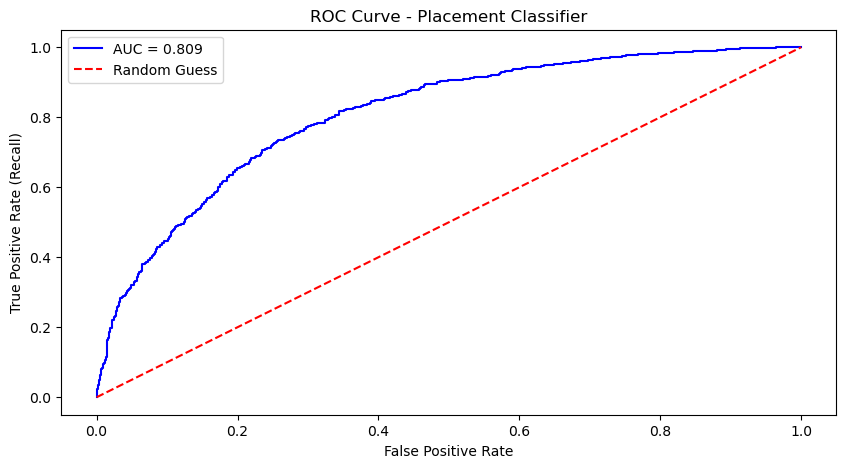

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, test_proba)
auc_score = roc_auc_score(y_test, test_proba)

plt.figure(figsize=(10,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.title('ROC Curve - Placement Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
# plt.savefig("../Images/roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

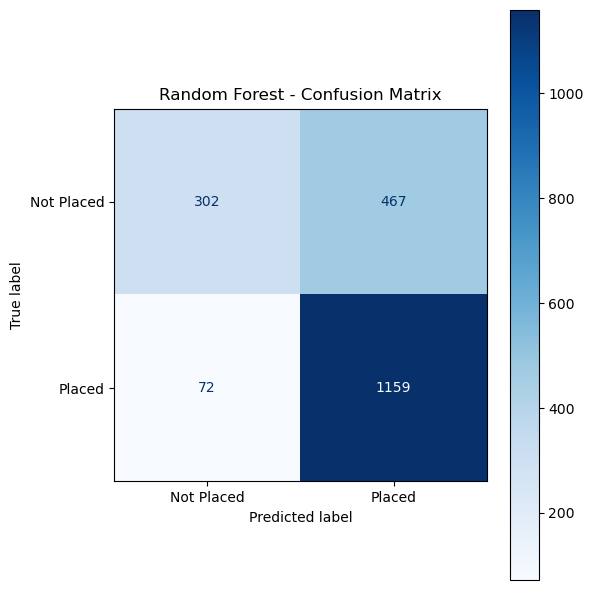

In [30]:
cm = confusion_matrix(y_test, best_test_pred)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Placed', 'Placed'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
# plt.savefig("../Images/random_forest_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

In [31]:
placement = df[df['placement_status'] == 1]

In [32]:
# Now for the salary prediction
x_reg = placement.drop(columns=['placement_status', 'salary'])
y_reg = placement['salary']

x_reg_train, x_reg_test, y_reg_train, y_reg_test = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=42
)

In [33]:
ohe_reg = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

reg_train_encoded = ohe_reg.fit_transform(x_reg_train[nominal_cols])
reg_test_encoded = ohe_reg.transform(x_reg_test[nominal_cols])

reg_train_encoded_df = pd.DataFrame(
    reg_train_encoded,
    columns=ohe_reg.get_feature_names_out(nominal_cols),
    index=x_reg_train.index
)
reg_test_encoded_df = pd.DataFrame(
    reg_test_encoded,
    columns=ohe_reg.get_feature_names_out(nominal_cols),
    index=x_reg_test.index
)

x_reg_train = x_reg_train.drop(columns=nominal_cols)
x_reg_test = x_reg_test.drop(columns=nominal_cols)
x_reg_train = pd.concat([x_reg_train, reg_train_encoded_df], axis=1)
x_reg_test = pd.concat([x_reg_test, reg_test_encoded_df], axis=1)

In [34]:
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(x_reg_train, y_reg_train)

rf_reg_train_pred = rf_reg.predict(x_reg_train)
rf_reg_test_pred = rf_reg.predict(x_reg_test)

print("── Random Forest Regressor──")
print(f"Train R²:  {r2_score(y_reg_train, rf_reg_train_pred):.3f}")
print(f"Test R²:   {r2_score(y_reg_test, rf_reg_test_pred):.3f}")
print(f"Gap:       {r2_score(y_reg_train, rf_reg_train_pred) - r2_score(y_reg_test, rf_reg_test_pred):.3f}")
print(f"Train MAE: {mean_absolute_error(y_reg_train, rf_reg_train_pred):,.0f}")
print(f"Test MAE:  {mean_absolute_error(y_reg_test, rf_reg_test_pred):,.0f}")

── Random Forest Regressor──
Train R²:  0.994
Test R²:   0.955
Gap:       0.039
Train MAE: 1,458
Test MAE:  3,865


The Random Forest Regressor performs strongly with a test R² of 0.956 and a MAE of ~$3,852 roughly a 5% average error across the salary range. The minimal train-test gap of 0.038 confirms the model generalizes well without significant overfitting.

In [35]:
param_distributions = {
    'n_estimators': [200, 300, 400],
    'max_depth': [15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [3, 4, 5]
}

random_search = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_distributions,  # note the 's'
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(x_reg_train, y_reg_train)

print("\nBest Parameters:", random_search.best_params_)
print(f"Best CV R²: {random_search.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_depth': 20}
Best CV R²: 0.955


In [36]:
# Best model is stored automatically
best_rf_reg = random_search.best_estimator_

rf_tuned_train_pred = best_rf_reg.predict(x_reg_train)
rf_tuned_test_pred = best_rf_reg.predict(x_reg_test)

print("── Tuned Random Forest ──")
print(f"Train R²:  {r2_score(y_reg_train, rf_tuned_train_pred):.3f}")
print(f"Test R²:   {r2_score(y_reg_test, rf_tuned_test_pred):.3f}")
print(f"Gap:       {r2_score(y_reg_train, rf_tuned_train_pred) - r2_score(y_reg_test, rf_tuned_test_pred):.3f}")
print(f"Train MAE: {mean_absolute_error(y_reg_train, rf_tuned_train_pred):,.0f}")
print(f"Test MAE:  {mean_absolute_error(y_reg_test, rf_tuned_test_pred):,.0f}")

── Tuned Random Forest ──
Train R²:  0.983
Test R²:   0.956
Gap:       0.026
Train MAE: 2,422
Test MAE:  3,832


Hyperparameter tuning yielded marginal gains, reducing the train-test gap from 0.038 to 0.026 with test R² and MAE having minute changes. This confirms the base Random Forest already captured the underlying patterns well, tuning primarily served to reduce the minimal overfitting that remained.

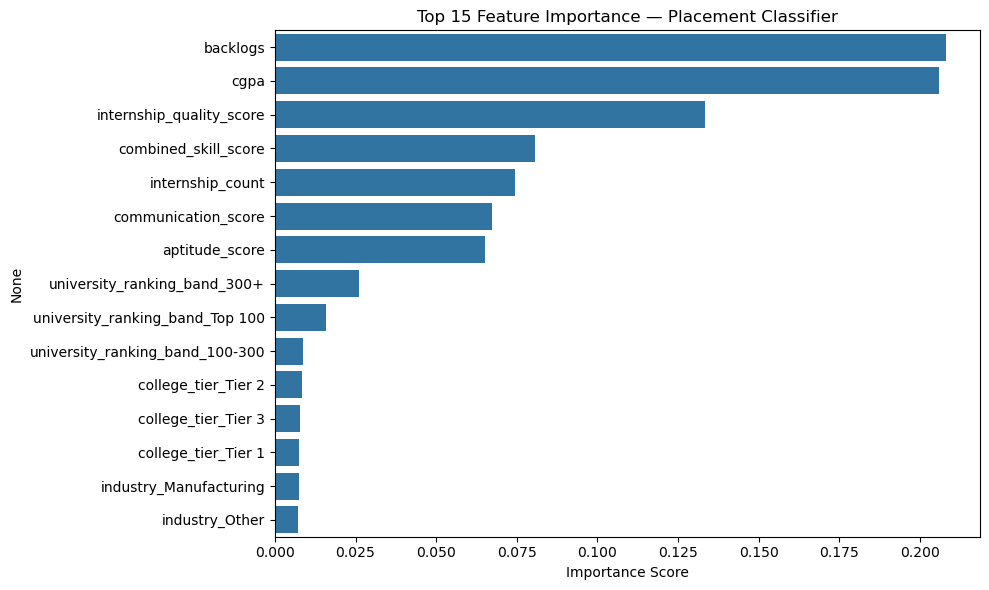

In [37]:
# feature importance of the Random Forest classifier
feat_imp_clf = pd.Series(
    best_rf.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_clf.values, y=feat_imp_clf.index)
plt.title('Top 15 Feature Importance — Placement Classifier')
plt.xlabel('Importance Score')
plt.tight_layout()
# plt.savefig('feature_importance_classifier.png', dpi=300, bbox_inches='tight')
plt.show()

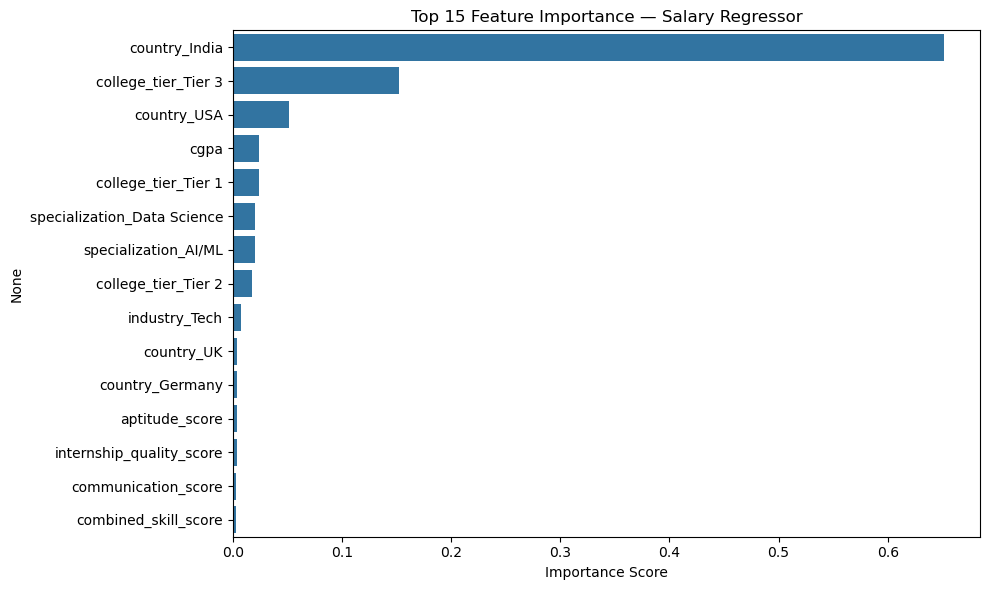

In [38]:
# feature importance of the Random Forest regressor
feat_imp_reg = pd.Series(
    best_rf_reg.feature_importances_,
    index=x_reg_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_reg.values, y=feat_imp_reg.index)
plt.title('Top 15 Feature Importance — Salary Regressor')
plt.xlabel('Importance Score')
plt.tight_layout()
# plt.savefig('feature_importance_regressor.png', dpi=300, bbox_inches='tight')
plt.show()

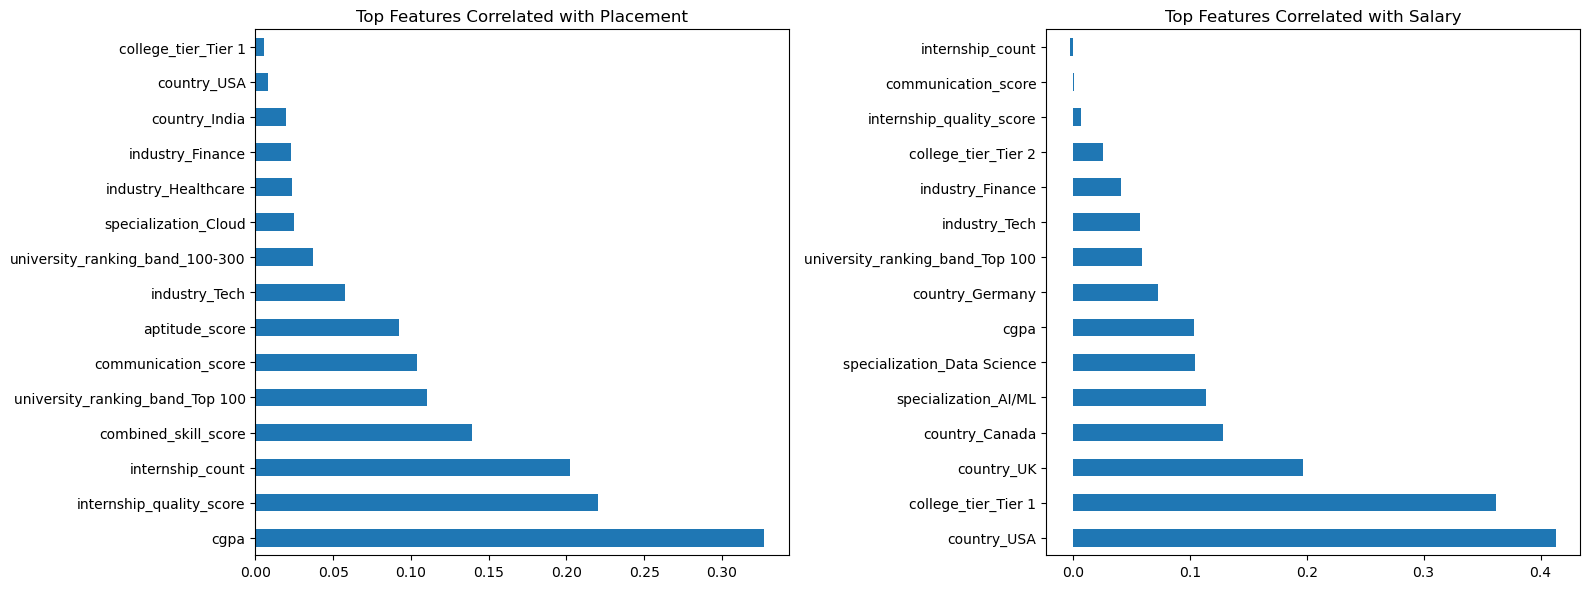

In [39]:
# Classifier correlation
clf_corr = pd.concat([x_train, y_train], axis=1).corr()['placement_status'].sort_values(ascending=False)

# Regressor correlation
reg_corr = pd.concat([x_reg_train, y_reg_train], axis=1).corr()['salary'].sort_values(ascending=False)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

clf_corr.drop('placement_status').head(15).plot(
    kind='barh', ax=axes[0], title='Top Features Correlated with Placement'
)
reg_corr.drop('salary').head(15).plot(
    kind='barh', ax=axes[1], title='Top Features Correlated with Salary'
)
plt.tight_layout()
# plt.savefig('feature_corelation.png', dpi=300, bbox_inches='tight')
plt.show()

Feature importance confirms the EDA narrative, CGPA and backlogs are the strongest placement predictors, while individual skill metrics contribute equally below them. Institutional factors like college tier and country rank near the bottom, reinforcing that placement is merit-driven. For salary, country of study dominates with India as the primary splitting feature, reflecting the dramatic market rate differences uncovered during EDA rather than any difference in candidate quality.

In [42]:
# lets see how our model should run in the fastapi app

# collect user inputs
cgpa = float(input('CGPA: '))
backlogs = int(input('Backlogs: '))
college_tier = input('Collect tier: ')
country = input('Country:')
university_ranking_band = input('University ranking band: ')
internship_count = int(input('Internship count: '))
aptitude_score = float(input('Aptitude score: '))
communication_score = float(input('Communication score: '))
specialization = input('Specialization: ')
industry = input('Industry: ')
internship_quality_score = float(input('Internship quality score: '))
combined_skill_score = aptitude_score + communication_score
print(f'combined_skill_score: {combined_skill_score}')

CGPA:  6
Backlogs:  3
Collect tier:  Tier 2
Country: UK
University ranking band:  Top 100
Internship count:  2
Aptitude score:  60
Communication score:  87
Specialization:  Cloud
Industry:  Other
Internship quality score:  7.4


combined_skill_score: 147.0


In [43]:
# build the data collected into a DataFrame and encode them

input_data = pd.DataFrame([{
    'cgpa': cgpa,
    'backlogs': backlogs,
    'college_tier': college_tier,
    'country': country,
    'university_ranking_band': university_ranking_band,
    'internship_count': internship_count,
    'aptitude_score': aptitude_score,
    'communication_score': communication_score,
    'specialization': specialization,
    'industry': industry,
    'internship_quality_score': internship_quality_score,
    'combined_skill_score': aptitude_score + communication_score 
}])

# encoding the data

encoded = ohe.transform(input_data[nominal_cols])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(nominal_cols)
)

input_data = input_data.drop(columns=nominal_cols)
input_data = pd.concat([input_data.reset_index(drop=True), encoded_df], axis=1)

In [44]:
# predict placement

proba = best_rf.predict_proba(input_data)[:, 1][0]
prediction = int(proba >= 0.4)
print(f"\nPlacement probability: {round(proba, 3)}")
print(f"\nPlacement status: {'Placed' if prediction == 1 else 'Not Placed'}")


Placement probability: 0.546

Placement status: Placed


In [45]:
# predict salary after placement
if prediction == 1:
    encoded_reg = ohe_reg.transform(pd.DataFrame([{
        'college_tier': college_tier,
        'country': country,
        'university_ranking_band': university_ranking_band,
        'specialization': specialization,
        'industry': industry
    }]))
    
    encoded_reg_df = pd.DataFrame(
        encoded_reg,
        columns = ohe_reg.get_feature_names_out(nominal_cols)
    )
    input_reg = input_data.drop(columns=ohe.get_feature_names_out(nominal_cols))
    input_reg = pd.concat([input_reg.reset_index(drop=True), encoded_reg_df], axis=1)
    
    salary = best_rf_reg.predict(input_reg)[0]
    print(f"Predicted salary: ${salary:,.2f}")

else:
    print("No salary estimate, student predicted as 'Not Placed'")

Predicted salary: $89,474.60


In [46]:
# saving thr models and encoders


# classifier
joblib.dump(best_rf, '../Models/placement_classifier.pkl')
joblib.dump(ohe, '../Models/placement_encoder.pkl')

# regressor
joblib.dump(best_rf_reg, '../Models/salary_regressor.pkl')
joblib.dump(ohe_reg, '../Models/salary_encoder.pkl')

['../Models/salary_encoder.pkl']